# Maternal Health Risk Prediction Using Machine Learning: A Clinical Data Approach

**Title of ML project : Maternal Health Risk Prediction Using Machine Learning: A Clinical Data Approach**<br>
**Name: Sruthi T S**<br>
**Organization: Entri Elevate**<br>
**Date: 27/05/2026**<br>

# 1. Overview of Problem Statement:
Maternal health during pregnancy is a critical global concern, particularly in low-resource clinical settings where timely risk assessment remains challenging. Complications arising from undetected high-risk pregnancies contribute significantly to maternal and neonatal mortality worldwide. Early identification of at-risk patients using routinely collected clinical parameters can enable timely medical intervention and improve outcomes. This project addresses this challenge by developing a machine learning based prediction model that classifies maternal health risk levels using basic clinical vitals and obstetric history, providing a cost-effective and scalable solution for risk assessment in healthcare settings.

# 2. Objective: 
To develop and evaluate machine learning classification models that accurately predict maternal health risk levels — High and Low — based on clinical and obstetric parameters, enabling early identification of high-risk pregnancies and supporting timely medical intervention

# 3. Data Description: 
**Source:**<br>
The dataset was obtained from Mendeley Data, a publicly available research data repository. It contains real-world clinical records collected from pregnant women across different age groups and risk categories.<br>

**Features:**<br>
Age, SystolicBP, DiastolicBP, BloodSugar, BodyTemp, BMI, PreviousComplications, PreexistingDiabetes, GestationalDiabetes, MentalHealth, HeartRate, RiskLevel (Target)<br>
Total Records: 1205<br>
Total Features: 12<br>


# 4. Data Collection

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

plt.style.use("seaborn-v0_8-whitegrid")

In [80]:
# Load the Dataset
df= pd.read_csv("Maternal_Health_Risk_Dataset.csv")

print("Dataset loaded successfully!")
print(f"shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

Dataset loaded successfully!
shape: 1205 rows × 12 columns



In [81]:

df.head()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low


In [82]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1205 non-null   int64  
 1   Systolic BP             1200 non-null   float64
 2   Diastolic               1201 non-null   float64
 3   BS                      1203 non-null   float64
 4   Body Temp               1205 non-null   int64  
 5   BMI                     1187 non-null   float64
 6   Previous Complications  1203 non-null   float64
 7   Preexisting Diabetes    1203 non-null   float64
 8   Gestational Diabetes    1205 non-null   int64  
 9   Mental Health           1205 non-null   int64  
 10  Heart Rate              1203 non-null   float64
 11  Risk Level              1187 non-null   object 
dtypes: float64(7), int64(4), object(1)
memory usage: 113.1+ KB


In [83]:
# Summary Statistics
df.describe()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate
count,1205.000000,1200.000000,1201.000000,1203.000000,1205.000000,1187.000000,1203.000000,1203.000000,1205.000000,1205.00000,1203.000000
mean,27.731950,116.819167,77.166528,7.501064,98.395851,23.315080,0.175395,0.288446,0.117842,0.33444,75.817124
std,12.571074,18.715502,14.305148,3.049522,1.088363,3.875682,0.380463,0.453228,0.322555,0.47199,7.227338
min,10.000000,70.000000,40.000000,3.000000,97.000000,0.000000,0.000000,0.000000,0.000000,0.00000,58.000000
25%,21.000000,100.000000,65.000000,6.000000,98.000000,20.450000,0.000000,0.000000,0.000000,0.00000,70.000000
50%,25.000000,120.000000,80.000000,6.900000,98.000000,23.000000,0.000000,0.000000,0.000000,0.00000,76.000000
75%,32.000000,130.000000,90.000000,7.900000,98.000000,25.000000,0.000000,1.000000,0.000000,1.00000,80.000000
max,325.000000,200.000000,140.000000,19.000000,103.000000,37.000000,1.000000,1.000000,1.000000,1.00000,92.000000


* The dataset contains 1,205 maternal health records with a relatively young population (mean age: 27.7 years) and includes a diverse range of clinical measurements relevant to pregnancy risk assessment. The average blood pressure and blood sugar values fall within pre-hypertensive and borderline-elevated ranges, indicating the presence of moderate health risk factors within the population.
*  Initial exploratory analysis also identified potential data quality issues, including an unrealistic maximum age value of 325 and a minimum BMI value of 0.0, which indicate the need for further preprocessing and cleaning in subsequent steps.
*   Among the binary clinical variables, Mental Health (33.4%) and Preexisting Diabetes (28.8%) were the most prevalent comorbidities, suggesting their possible relevance in maternal health risk assessment.

In [84]:
print("Column Names")
print(df.columns.tolist())

Column Names
['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Previous Complications', 'Preexisting Diabetes', 'Gestational Diabetes', 'Mental Health', 'Heart Rate', 'Risk Level']


In [85]:
# Renaming the columns
df.rename(columns= {
    'Systolic BP': 'SystolicBP',
    'Diastolic': 'DiastolicBP',
    'BS': 'BloodSugar',
    'Body Temp': 'BodyTemp',
    'BMI': 'BMI',
    'Previous Complications': 'PreviousComplications',
    'Preexisting Diabetes': 'PreexistingDiabetes',
    'Gestational Diabetes': 'GestationalDiabetes',
    'Mental Health': 'MentalHealth',
    'Heart Rate': 'HeartRate',
    'Risk Level': 'RiskLevel'
}, inplace=True)

# Verify new column names
print("Modified Column Names")
print(df.columns)

Modified Column Names
Index(['Age', 'SystolicBP', 'DiastolicBP', 'BloodSugar', 'BodyTemp', 'BMI',
       'PreviousComplications', 'PreexistingDiabetes', 'GestationalDiabetes',
       'MentalHealth', 'HeartRate', 'RiskLevel'],
      dtype='object')


* Column names were standardized by removing spaces and expanding abbreviations for improved code readability and consistency throughout the analysis

In [86]:
# Check Class Distribution and Missing Values in Risk Level
print("Target Variable: Risk Level")
print(df["RiskLevel"].value_counts(dropna=False))

Target Variable: Risk Level
RiskLevel
Low     713
High    474
NaN      18
Name: count, dtype: int64


* The target variable showed a moderate class imbalance, with Low Risk cases representing approximately 60% of the dataset and High Risk cases accounting for 40%.
*  Although the imbalance is not severe, stratified sampling and additional evaluation metrics such as precision, recall, and F1-score were considered to ensure reliable model performance across both classes.
*  Additionally, 18 missing values were identified in the Risk Level column, indicating the need for handling missing target labels during preprocessing.

# 5. Data Preprocessing - Data Cleaning

In [87]:
# Remove the Missing Values in Target Variable
df= df[df["RiskLevel"].notna().copy()]
print(f"Updated dataset shape after removing missing values: {df.shape}")

Updated dataset shape after removing missing values: (1187, 12)


In [88]:
# Duplicate Rows
dup_count= df.duplicated().sum()
print(f" Duplicates found: {dup_count}")

# Remove Duplicate Rows
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape:{df.shape}")


 Duplicates found: 18
Duplicates removed. New shape:(1169, 12)


In [89]:
# Missing Values in Features
print("Missing Feature Values")
print(df.isnull().sum())

continuous_cols = ['Age', 'SystolicBP', 'DiastolicBP', 'BloodSugar', 'BodyTemp', 'BMI', 'HeartRate']
binary_cols = ['PreviousComplications', 'PreexistingDiabetes', 'GestationalDiabetes', 'MentalHealth']

# Filling missing continuous values with column median
for col in continuous_cols:
    if df[col].isnull().sum() >0:
        median_val= df[col].median()
        df[col]= df[col].fillna(median_val)
        print(f" Filled '{col}' missing values with {median_val} ")

for col in binary_cols:
    if df[col].isnull().sum() >0:
        mode_val= df[col].mode()[0]
        df[col]= df[col].fillna(mode_val)
        print(f" Filled '{col}' missing values with {int(mode_val)}'")

Missing Feature Values
Age                       0
SystolicBP                4
DiastolicBP               2
BloodSugar                1
BodyTemp                  0
BMI                      14
PreviousComplications     1
PreexistingDiabetes       1
GestationalDiabetes       0
MentalHealth              0
HeartRate                 1
RiskLevel                 0
dtype: int64
 Filled 'SystolicBP' missing values with 120.0 
 Filled 'DiastolicBP' missing values with 80.0 
 Filled 'BloodSugar' missing values with 6.9 
 Filled 'BMI' missing values with 23.0 
 Filled 'HeartRate' missing values with 76.0 
 Filled 'PreviousComplications' missing values with 0'
 Filled 'PreexistingDiabetes' missing values with 0'


In [90]:
print(f"   Remaining missing: {df.isnull().sum().sum()}")

   Remaining missing: 0


* Missing values were identified in SystolicBP, DiastolicBP, BloodSugar, BMI, HeartRate, PreviousComplications, and PreexistingDiabetes, while the remaining features had no missing values. Continuous variables were imputed using the median of each feature to minimize the effect of outliers, whereas binary variables were imputed using the mode to preserve class distribution.
* After imputation, no missing values remained in the dataset, confirming successful data preprocessing for further analysis.

In [91]:
# Data Type Conversion
print("Data Type Conversion")

for col in binary_cols:
    df[col]= df[col].astype(int)
    print(f" '{col}'---> int")

Data Type Conversion
 'PreviousComplications'---> int
 'PreexistingDiabetes'---> int
 'GestationalDiabetes'---> int
 'MentalHealth'---> int


* After fillna, binary columns may still be float (e.g., 1.0 → 1). Converting to int makes them cleaner and semantically correct.

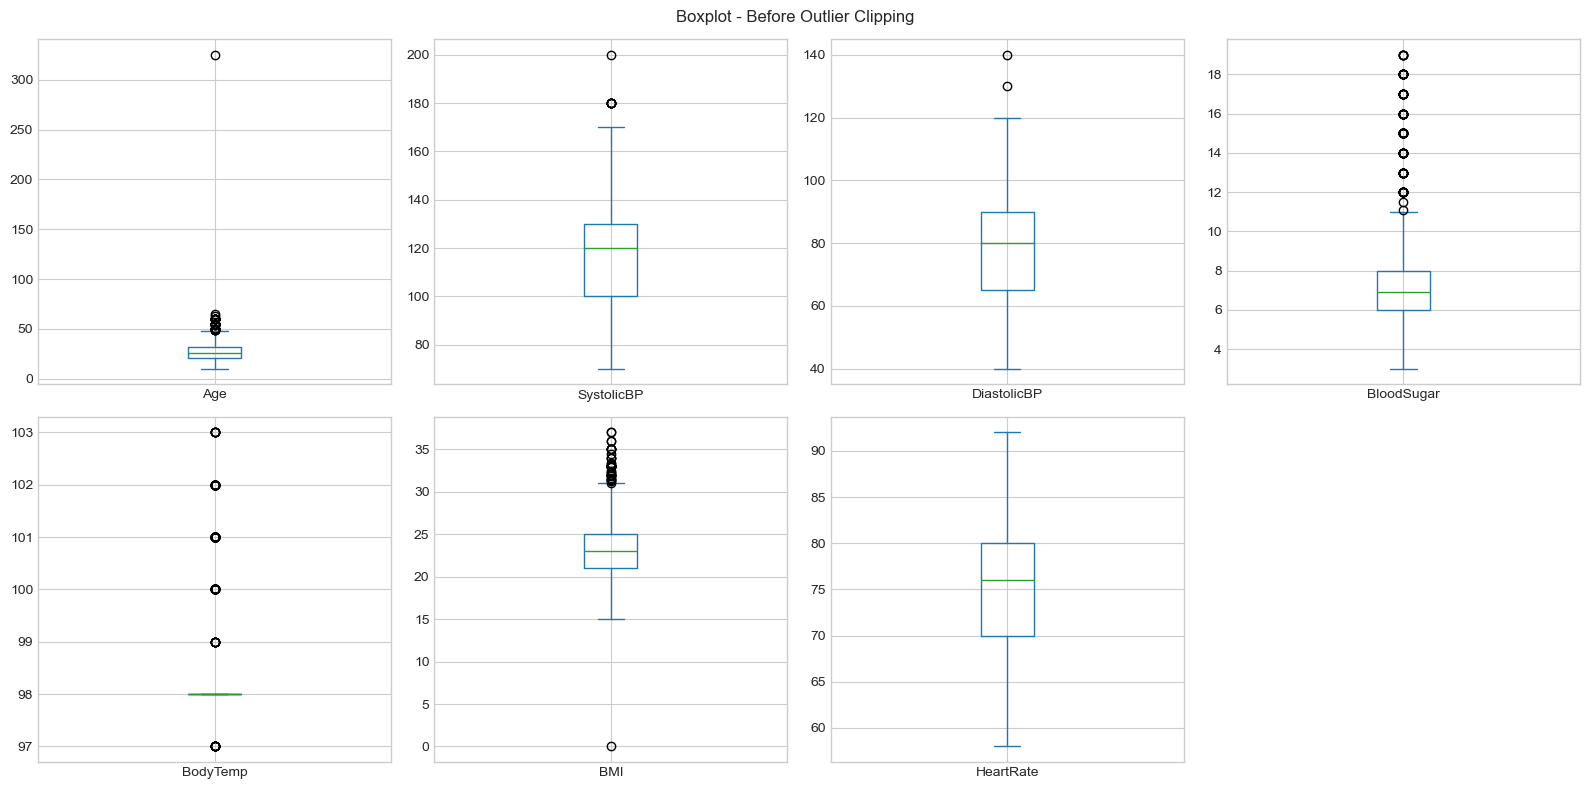

In [92]:
# Outlier Detection and Handling
# Boxplot before outlier treatment
num_cols = ['Age', 'SystolicBP', 'DiastolicBP', 'BloodSugar', 
            'BodyTemp', 'BMI', 'HeartRate']
df[num_cols].plot(kind='box', subplots=True, layout=(2,4), 
                  figsize=(16,8), title='Boxplot - Before Outlier Clipping')
plt.tight_layout()
plt.show()

* Outlier detection is essential in clinical datasets as extreme or erroneous values can distort model training and lead to inaccurate predictions. Identifying and treating outliers ensures the model learns from realistic and clinically valid data patterns.

* The boxplot reveals the presence of extreme outliers in Age and BMI. 
Age shows a value as high as 325 years which is impossible value.
* BMI also contains near-zero values which are 
clinically invalid. These anomalies confirm the need for outlier treatment 
before model training.

In [93]:
# Definig clinical bounds and applying capping
clinical_bounds = {
    'Age': (18, 55),
    'BMI': (15, 45)
}
for col, (lower, upper) in clinical_bounds.items():
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outliers} outliers | clinical bounds [{lower}, {upper}]")
    df[col] = np.clip(df[col], lower, upper)

print('SystolicBP: no clipping — values clinically valid for maternal health')
print('DiastolicBP: no clipping — values clinically valid for maternal health')
print('BloodSugar: no clipping — already within clinical range')
print('BodyTemp: no clipping — near constant distribution')
print('HeartRate: no clipping — no outliers detected')

Age: 105 outliers | clinical bounds [18, 55]
BMI: 1 outliers | clinical bounds [15, 45]
SystolicBP: no clipping — values clinically valid for maternal health
DiastolicBP: no clipping — values clinically valid for maternal health
BloodSugar: no clipping — already within clinical range
BodyTemp: no clipping — near constant distribution
HeartRate: no clipping — no outliers detected


* Outlier detection was performed using clinically informed bounds rather than purely statistical IQR thresholds, as statistical bounds produced physiologically unrealistic ranges for maternal health data. Values falling outside medically acceptable limits were capped to the nearest clinical boundary instead of being removed. This approach helped preserve all patient records while reducing the influence of unrealistic extreme values and maintaining clinical relevance of the dataset.
* Only Age and BMI were identified as requiring treatment based on the presence of clinically impossible values — Age entries exceeding 55 years or below 18 years, and BMI values approaching zero.
*  The remaining features including SystolicBP, DiastolicBP, BloodSugar, BodyTemp, and HeartRate were retained without clipping as their ranges fall within clinically acceptable limits for pregnant women.

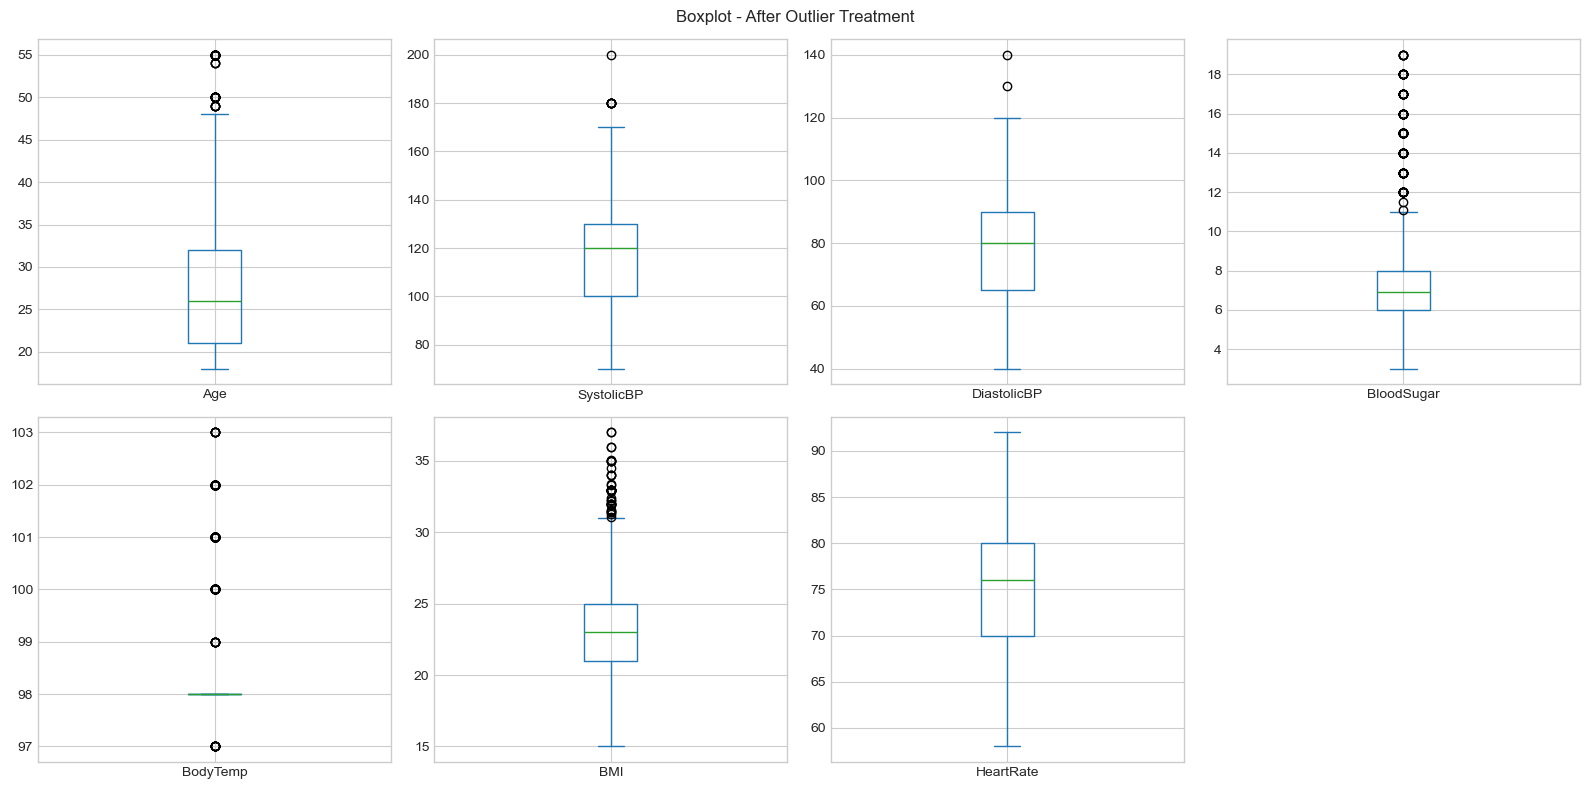

In [94]:
# Boxplot after outlier treatment
df[num_cols].plot(kind='box', subplots=True, layout=(2,4),
                  figsize=(16,8), 
                  title='Boxplot - After Outlier Treatment')
plt.tight_layout()
plt.show()

* Post-treatment boxplots confirm that Age and BMI now fall within realistic clinical ranges. Age is bounded between 18 and 55 years, consistent with standard maternal health guidelines.
* BMI ranges between 15 and 45, covering underweight to severely obese categories relevant to pregnancy risk. Blood pressure, blood sugar, body temperature, and heart rate distributions remain unchanged and show clinically valid ranges with minimal extreme values.

# 6. Feature Engineering

In [95]:
print(df['RiskLevel'].unique())

['High' 'Low']


In [96]:
# Label Encoding of Target Variable
le= LabelEncoder()
df["RiskLevel"] = le.fit_transform(df['RiskLevel'])
print(dict(zip(le.classes_, le.transform(le.classes_))))
print(df["RiskLevel"].value_counts())

{'High': np.int64(0), 'Low': np.int64(1)}
RiskLevel
1    696
0    473
Name: count, dtype: int64


* Label Encoding was applied to convert the categorical target variable RiskLevel into numerical format, as machine learning algorithms require numerical input for model training
* High risk is encoded as 0 and Low risk as 1

# 7. Exploratory Data Analysis(EDA)

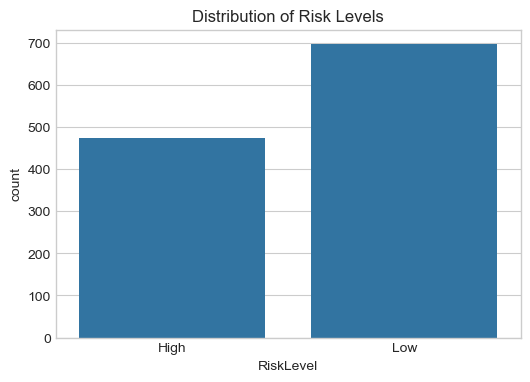

In [97]:
# 7.1 Target Variable Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="RiskLevel", data=df)
plt.title("Distribution of Risk Levels")
plt.xticks([0,1], ['High', 'Low'])
plt.show()

* The dataset contains 473 High risk and 696 Low risk cases, 
revealing a class imbalance where Low risk cases outnumber 
High risk cases.
* This imbalance could bias the model towards 
predicting Low risk more frequently, justifying the need for 
SMOTE resampling before model training.

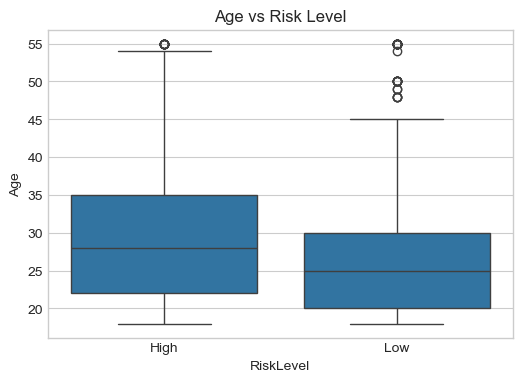

In [98]:
# 7.2 Age Distribution by Risk Level
plt.figure(figsize=(6,4))
sns.boxplot(x= "RiskLevel", y="Age", data=df)
plt.title("Age vs Risk Level")
plt.xticks([0,1], ['High', 'Low'])
plt.show()

* High risk pregnancies show a higher median age (approximately 
28 years) compared to Low risk pregnancies (approximately 25 
years).
* The wider interquartile range in High risk cases 
suggests that maternal age is a contributing factor to risk 
level, with older pregnant women showing a greater tendency 
towards High risk classification.

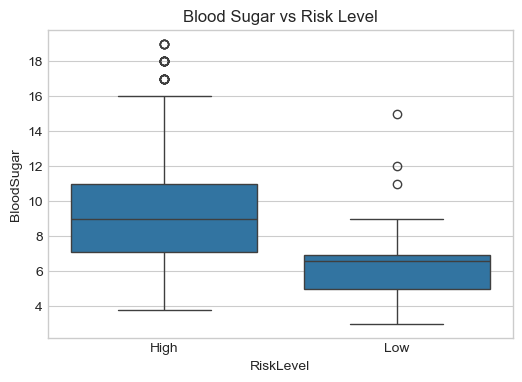

In [99]:
# 7.3 Blood Sugar vs Risk Level
plt.figure(figsize=(6,4))
sns.boxplot(x= "RiskLevel", y="BloodSugar", data=df)
plt.title("Blood Sugar vs Risk Level")
plt.xticks([0,1], ["High", "Low"])
plt.show()


* The boxplot analysis indicated that high-risk patients generally exhibited higher blood sugar levels compared to low-risk patients. The high-risk group also showed greater variability and several extreme values, suggesting that elevated blood sugar may contribute significantly to maternal health risk prediction.

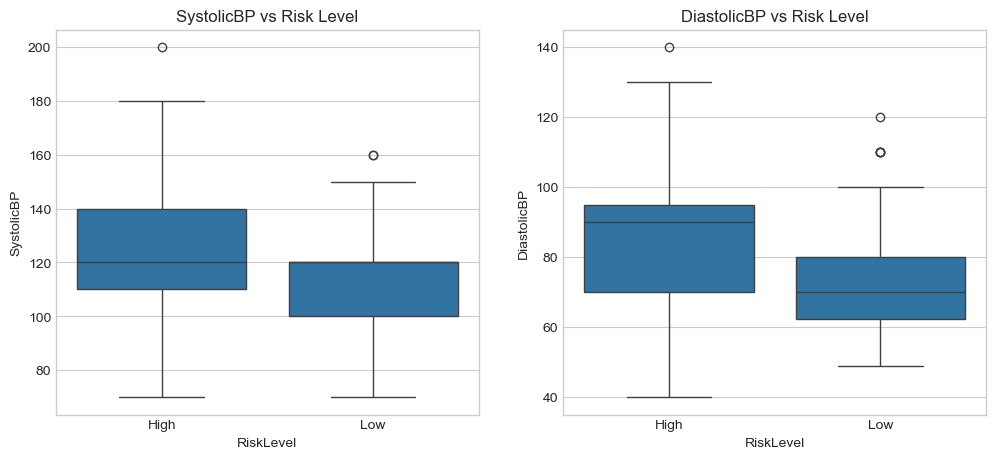

In [100]:
# 7.4 Blood Pressure vs Risk Level
fig, axes=plt.subplots(1,2, figsize=(12,5))
cols= ['SystolicBP', 'DiastolicBP']
for ax, col in zip (axes, cols):
    sns.boxplot(x= "RiskLevel", y=col, data=df, ax=ax)
    ax.set_xticklabels(['High', 'Low'])
    ax.set_title(f"{col} vs Risk Level")
plt.show()

* Boxplot analysis showed that both systolic and diastolic blood pressure values were generally higher among high-risk patients compared to low-risk patients, suggesting a possible association between elevated blood pressure and maternal health risk.

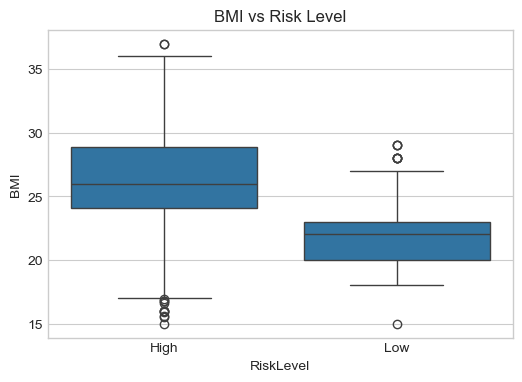

In [101]:
# 7.5 BMI vs Risk Level
plt.figure(figsize=(6,4))
sns.boxplot(x= "RiskLevel", y= "BMI", data=df)
plt.title("BMI vs Risk Level")
plt.xticks([0,1], ['High', 'Low'])
plt.show()
          

* BMI distribution showed that high-risk patients generally had higher BMI values than low-risk patients, with greater variability and several outliers. This suggests that abnormal BMI levels—both high and low—may be associated with increased maternal health risk

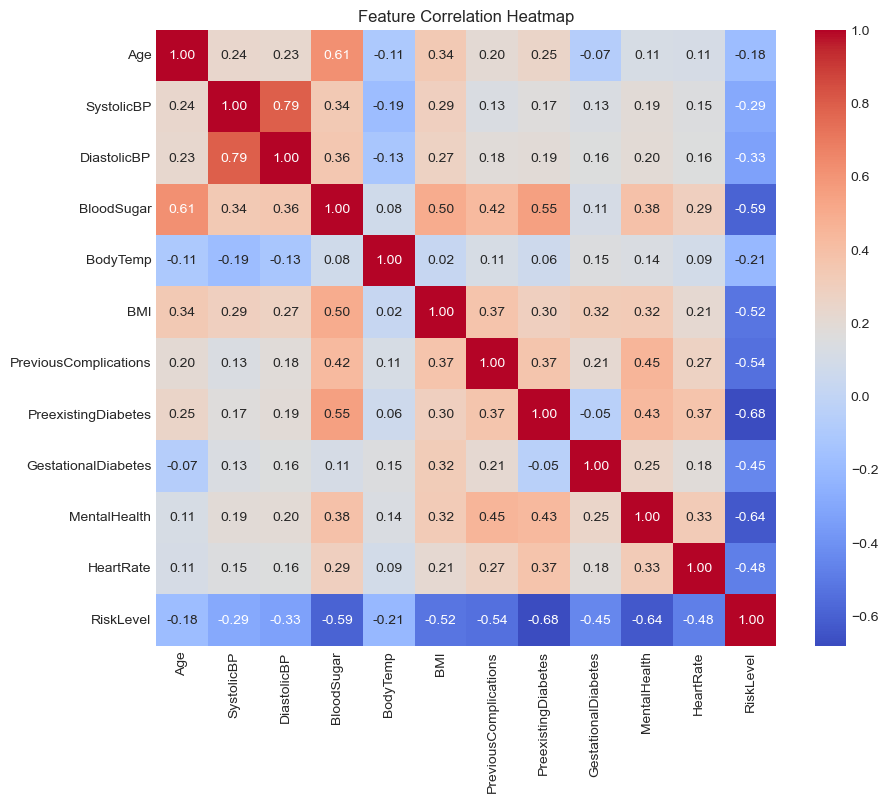

In [102]:
# 7.6 Feature Correletion Heatmap
plt.figure(figsize= (10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

* The correlation heatmap was used to examine the relationships among clinical features and the target variable, RiskLevel. The analysis showed that PreexistingDiabetes had the strongest negative relationship with RiskLevel, followed by MentalHealth and BloodSugar, indicating that these are major predictors of maternal health risk.
*  BMI and PreviousComplications also showed moderate to strong negative associations, suggesting their important role in identifying high-risk pregnancies. SystolicBP and DiastolicBP showed moderate negative correlation with RiskLevel and were strongly positively correlated with each other, which is clinically expected.
*   In contrast, BodyTemp showed the weakest relationship with RiskLevel, indicating lower predictive importance in this dataset. Overall, the heatmap highlights PreexistingDiabetes, MentalHealth, BloodSugar, BMI, and PreviousComplications as the most influential features for maternal health risk prediction

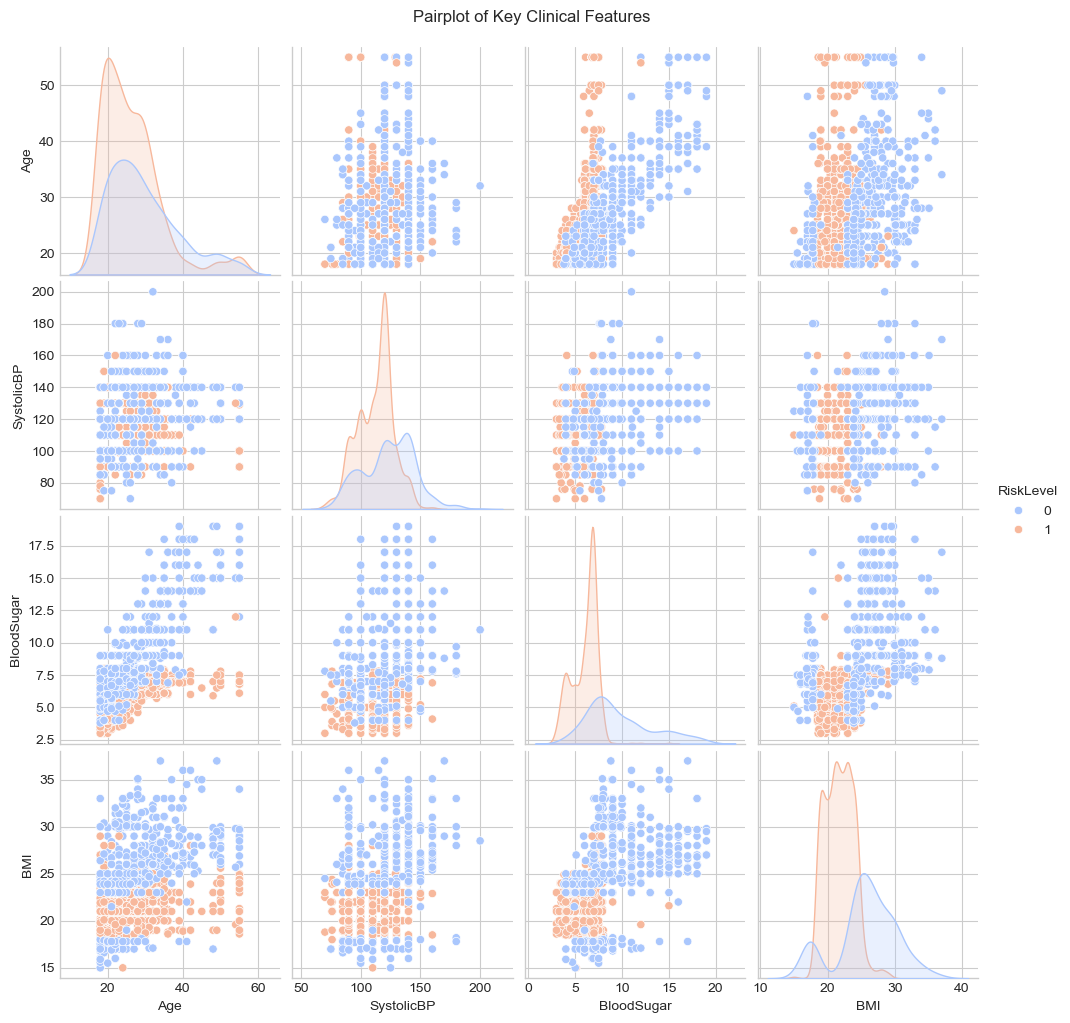

In [103]:
# 7.7 Pairplot of Key Features
sns.pairplot(df[['Age', 'SystolicBP', 'BloodSugar', 'BMI', 'RiskLevel']], hue='RiskLevel', palette='coolwarm')
plt.suptitle('Pairplot of Key Clinical Features', y=1.02)
plt.show()             

* The pairplot illustrates the pairwise relationships among Age, SystolicBP, BloodSugar, and BMI, with observations color-coded by RiskLevel. The diagonal density plots indicate that BloodSugar provides the clearest separation between High and Low risk groups, with high-risk cases concentrated at elevated glucose levels, highlighting its strong predictive significance.
* BMI also demonstrates noticeable separation between the two classes, while Age and SystolicBP exhibit comparatively greater overlap. Scatter plots involving BloodSugar show relatively distinct clustering patterns, further supporting its importance in maternal health risk prediction.
* Feature combinations such as Age with SystolicBP or BMI display substantial overlap between risk groups, suggesting that individual variables alone may not sufficiently distinguish maternal risk levels. Overall, the pairplot indicates that although certain features such as BloodSugar and BMI contribute strongly to class differentiation, the combined effect of multiple clinical variables is essential for accurate maternal health risk classification.

# 8. Data Preparation for Model Training

In [104]:
# Define Features and Target
X = df.drop("RiskLevel", axis=1)
y = df["RiskLevel"]

print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (1169, 11)
Target shape: (1169,)


In [105]:
# Train Test Split 
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=42)
print('Training set size:', X_train.shape)
print('Testing set size :', X_test.shape)

Training set size: (935, 11)
Testing set size : (234, 11)


* The dataset was split into 80% training (935 samples) and 
20% testing (234 samples) sets using stratified sampling 
to preserve the original class proportions.

In [106]:
# Class Imbalance Treatment using SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print('Before SMOTE:')
print(pd.Series(y_train).value_counts())
print('\nAfter SMOTE:')
print(pd.Series(y_train_resampled).value_counts())

Before SMOTE:
RiskLevel
1    557
0    378
Name: count, dtype: int64

After SMOTE:
RiskLevel
0    557
1    557
Name: count, dtype: int64


* SMOTE was applied exclusively on the training data to address the class imbalance, synthetically generating 179 additional High risk samples to match the majority Low risk class count of 557
* The test set was intentionally left in its 
original imbalanced state to reflect real world evaluation 
conditions

In [107]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("Scaling applied successfully")

Scaling applied successfully


* StandardScaler was subsequently applied by fitting on the resampled training data and transforming both training and test sets independently, ensuring no data leakage from the test set into the training pipeline.

# 9. Model Building and Evaluation

In [108]:
# Import Libraries
!pip install xgboost
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve)


In [109]:
# Define Models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(random_state=42),
    'XGBoost'            : XGBClassifier(random_state=42, eval_metric="logloss"),
    'SVM'                : SVC(probability=True, random_state=42)
}

# Train and Evaluate All Models
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train_resampled)
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    # Store results
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'AUC'     : roc_auc_score(y_test, y_pred),
        'y_pred'  : y_pred,
        'y_prob'  : y_prob
    }
    
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Accuracy : {results[name]['Accuracy']:.4f}")
    print(f"AUC Score : {results[name]['AUC']:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['High', 'Low']))


  Logistic Regression
Accuracy : 0.9786
AUC Score : 0.9787

Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.98      0.97        95
         Low       0.99      0.98      0.98       139

    accuracy                           0.98       234
   macro avg       0.98      0.98      0.98       234
weighted avg       0.98      0.98      0.98       234


  Decision Tree
Accuracy : 0.9444
AUC Score : 0.9432

Classification Report:
              precision    recall  f1-score   support

        High       0.93      0.94      0.93        95
         Low       0.96      0.95      0.95       139

    accuracy                           0.94       234
   macro avg       0.94      0.94      0.94       234
weighted avg       0.94      0.94      0.94       234


  Random Forest
Accuracy : 0.9744
AUC Score : 0.9784

Classification Report:
              precision    recall  f1-score   support

        High       0.94      1.00      0.97        

* Five classification algorithms were selected for this project — Logistic Regression as a linear baseline, Decision Tree for interpretability, Random Forest and XGBoost as ensemble methods, and Support Vector Machine as a kernel based classifier. This diverse selection enables a comprehensive comparison across different algorithmic approaches for maternal health risk classification.
* All five models demonstrated strong predictive performance. Logistic Regression achieved the highest accuracy of 97.86% and AUC of 0.9787, followed by Random Forest and XGBoost both at 97.44%, SVM at 97.01% and Decision Tree at 94.44%. The consistently high performance across all models confirms the strong predictive power of the selected clinical features.

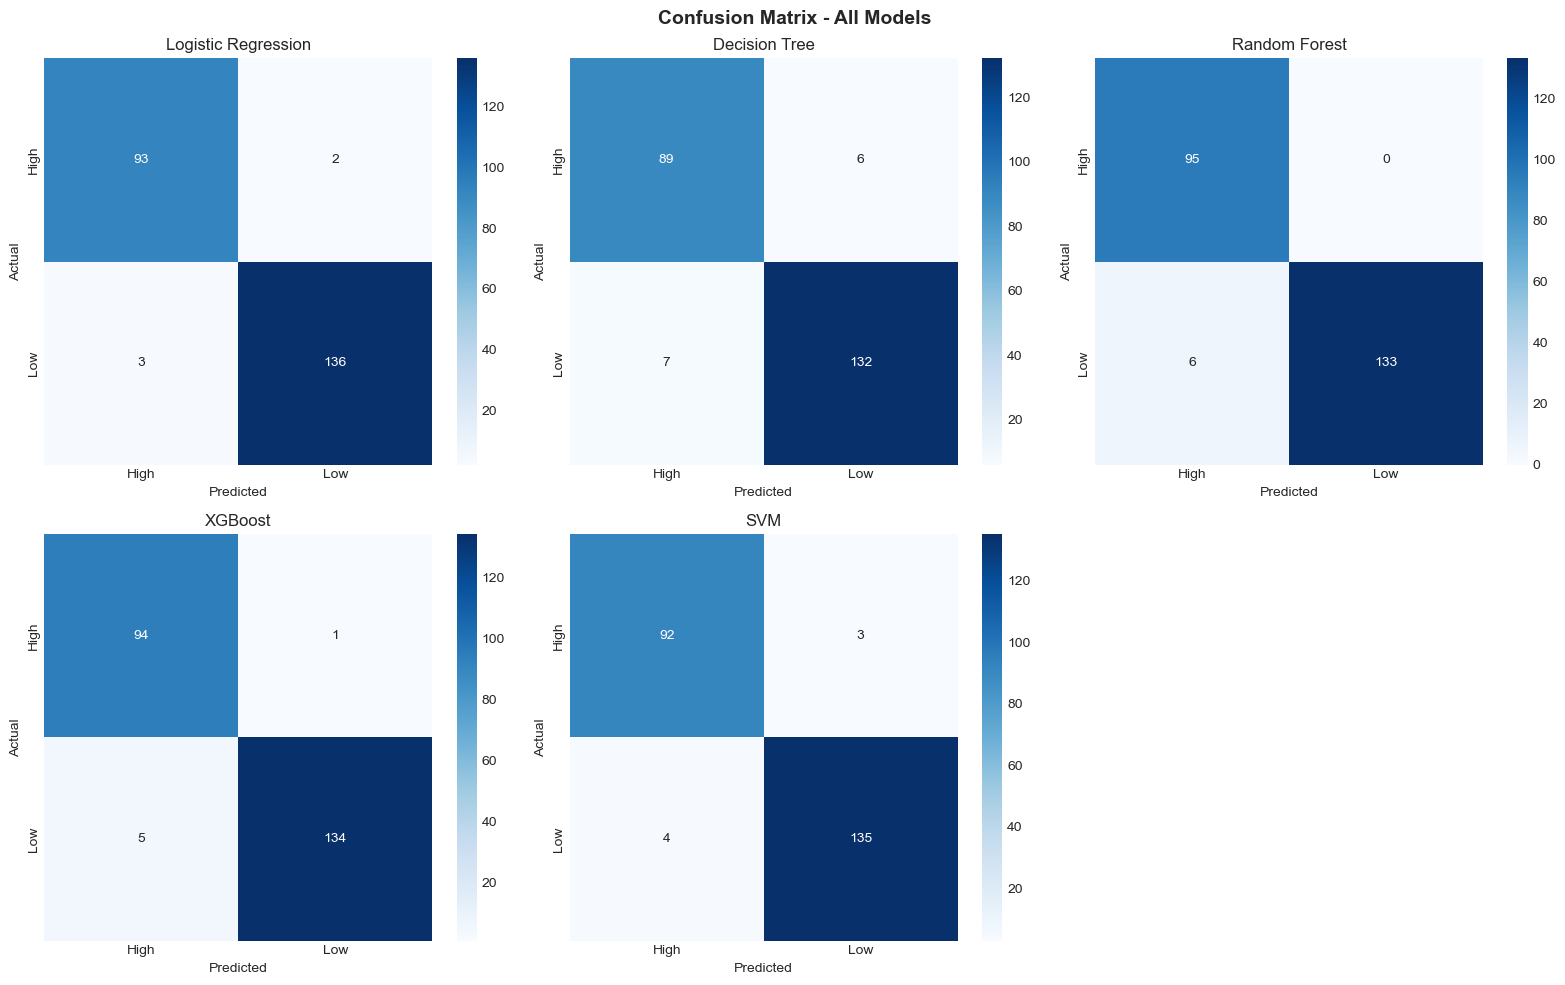

In [110]:
# Confusion Metrix - All Models
fig, axes = plt.subplots(2,3, figsize= (16,10))
axes = axes.flatten()

for i, (name,result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['y_pred'])
    sns.heatmap(cm, annot= True, fmt= "d", cmap="Blues",
               xticklabels=["High", "Low"],
               yticklabels=["High", "Low"],
               ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

axes[-1].set_visible(False)
plt.suptitle("Confusion Matrix - All Models", fontsize= 14, fontweight="bold")
plt.tight_layout()
plt.show()

* Confusion matrices revealed that Logistic Regression produced the best balance between false positives and false negatives with only 2 false negatives and 3 false positives.
* Random Forest achieved a perfect High risk recall with zero false negatives, making it the most clinically conservative model.
* Decision Tree recorded the highest misclassification counts among all models

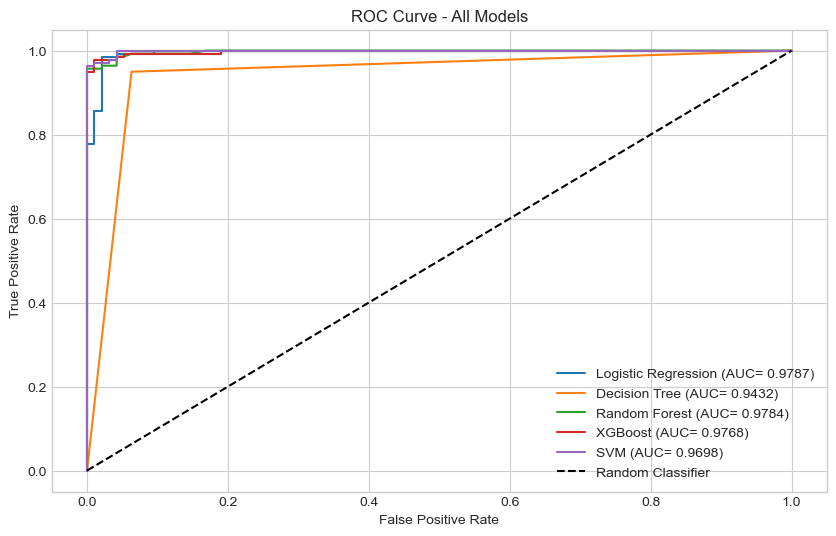

In [111]:
#  ROC Curve and AUC Score Comparison
plt.figure(figsize=(10,6))

for name, result in results.items():
    fpr, tpr,_= roc_curve(y_test, result["y_prob"])
    auc = result["AUC"]
    plt.plot(fpr, tpr, label= f"{name} (AUC= {auc:.4f})")

plt.plot([0,1], [0,1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - All Models")
plt.legend(loc="lower right")
plt.show()

* The ROC curve was used to evaluate each model's ability to discriminate between High and Low risk classes across all classification thresholds, providing a more comprehensive performance measure than accuracy alone — particularly valuable in clinical settings where class imbalance exists.
* Logistic Regression achieved the highest AUC of 0.9787, followed by Random Forest (0.9784) and XGBoost (0.9768).
*  All models except Decision Tree clustered tightly in the upper left region of the plot, indicating strong and comparable discrimination ability between risk classes

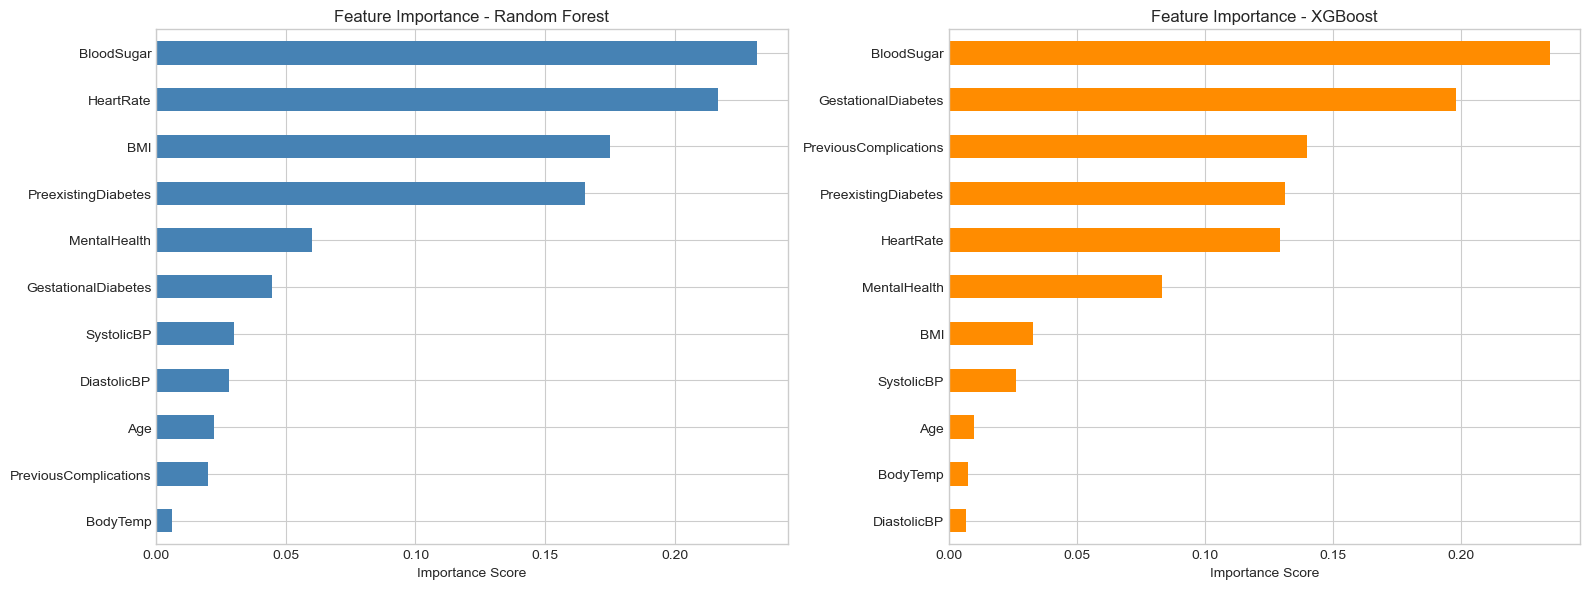

In [112]:
# Feature Importance - Random Forest and XGBoost
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
rf_importance = pd.Series(models['Random Forest'].feature_importances_,index=X.columns).sort_values()

rf_importance.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance - Random Forest')
axes[0].set_xlabel('Importance Score')

# XGBoost
xgb_importance = pd.Series(models['XGBoost'].feature_importances_,index=X.columns).sort_values()

xgb_importance.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Feature Importance - XGBoost')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

* Feature importance scores were extracted from Random Forest and XGBoost models to identify the most influential clinical and obstetric variables in predicting maternal health risk
* Both models consistently identified BloodSugar as the most important feature, recording the highest importance score in both Random Forest and XGBoost. This aligns with the strong negative correlation of -0.59 observed during EDA and the clear class separation visible in the Blood Sugar vs Risk Level boxplot, confirming blood glucose as the primary clinical indicator of maternal risk
* Random Forest also assigned high importance to HeartRate, BMI, and PreexistingDiabetes, while XGBoost gave higher importance to GestationalDiabetes and PreviousComplications. BodyTemp showed the lowest importance in both models.
* Overall, the feature importance analysis indicates that metabolic and diabetes-related indicators—particularly BloodSugar, PreexistingDiabetes, and GestationalDiabetes—along with HeartRate, are the strongest predictors of maternal health risk in this dataset.

In [113]:
# Cross Validation on Best Model (Logistic Regression)
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

best_pipeline = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(random_state=42))])

cv_scores = cross_val_score(best_pipeline, X, y, cv=5, scoring='accuracy')

print(f'CV Scores     : {cv_scores}')
print(f'Mean Accuracy : {cv_scores.mean():.4f}')
print(f'Std Deviation : {cv_scores.std():.4f}')

CV Scores     : [0.96153846 0.96153846 0.97863248 0.94871795 0.83690987]
Mean Accuracy : 0.9375
Std Deviation : 0.0512


* To assess model generalization before hyperparameter optimization, 5-fold cross-validation was performed on Logistic Regression using a pipeline with StandardScaler to ensure leakage-free evaluation.
* The model achieved a mean cross-validation accuracy of 93.75% with a standard deviation of 0.0512. Four out of five folds recorded accuracy above 94%, indicating stable performance across different training–validation splits.
* The slightly lower score in one fold (83.69%) may be due to natural variation in class distribution within that split, since SMOTE was not applied during cross-validation.
* Overall, these results indicate that the model generalizes well and that the strong test accuracy of 97.86% is unlikely to be due to overfitting.

# 10. Hyperparameter Tuning

In [114]:
# Hyperparameter Tuning - Logistic Regression (Best Model)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C'      : [0.01, 0.1, 1, 10, 100],
    'solver' : ['lbfgs', 'liblinear'],
    'max_iter': [100, 200, 500]
}

grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1)

grid_search.fit(X_train_scaled, y_train_resampled)

print(f'Best Parameters : {grid_search.best_params_}')
print(f'Best CV Accuracy: {grid_search.best_score_:.4f}')

# Train final model with best parameters
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)

print(f'\nTuned Model Test Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}')
print(classification_report(y_test, y_pred_tuned, 
                            target_names=['High', 'Low']))

Best Parameters : {'C': 10, 'max_iter': 100, 'solver': 'lbfgs'}
Best CV Accuracy: 0.9578

Tuned Model Test Accuracy: 0.9786
              precision    recall  f1-score   support

        High       0.97      0.98      0.97        95
         Low       0.99      0.98      0.98       139

    accuracy                           0.98       234
   macro avg       0.98      0.98      0.98       234
weighted avg       0.98      0.98      0.98       234



* Hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation to optimize the Logistic Regression model.
* The best hyperparameters were identified as C = 10, solver = 'lbfgs', and max_iter = 100, yielding a best cross-validation accuracy of 95.78%. The tuned model achieved a test accuracy of 97.86%, which was comparable to the baseline Logistic Regression model.
* This indicates that while hyperparameter tuning improved cross-validation performance, the baseline model already performed strongly on the test set, confirming the robustness and stability of Logistic Regression for maternal health risk prediction.

# 11. Save the Model

In [115]:
# Save the Model
import joblib
import os

# Create project folder if not exists
os.makedirs('maternal_health_risk_project', exist_ok=True)

# Save model and scaler
joblib.dump(best_model, 
            'maternal_health_risk_project/maternal_health_risk_model.pkl')
joblib.dump(scaler, 
            'maternal_health_risk_project/scaler.pkl')

print('Model saved successfully')
print('Scaler saved successfully')

Model saved successfully
Scaler saved successfully


* The best trained Logistic Regression model and StandardScaler were saved using joblib for future deployment and inference 

# 12. Test with Useen Data

In [116]:
# Test with Unseen Data
# Load saved model and scaler
loaded_model = joblib.load(
    'maternal_health_risk_project/maternal_health_risk_model.pkl')
loaded_scaler = joblib.load(
    'maternal_health_risk_project/scaler.pkl')

# Sample unseen patient record
unseen_data = pd.DataFrame([[28, 130, 90, 12.0, 98, 32.5, 1, 1, 0, 1, 82]], columns=X.columns)

# Scale using saved scaler
unseen_scaled = loaded_scaler.transform(unseen_data)

# Predict
prediction = loaded_model.predict(unseen_scaled)
probability = loaded_model.predict_proba(unseen_scaled)

print('Patient Clinical Details:')
print(unseen_data.T.to_string(header=False))
print(f'\nPredicted Risk Level : {"High" if prediction[0] == 0 else "Low"}')
print(f'High Risk Probability: {probability[0][0]:.4f}')
print(f'Low Risk Probability : {probability[0][1]:.4f}')

Patient Clinical Details:
Age                     28.0
SystolicBP             130.0
DiastolicBP             90.0
BloodSugar              12.0
BodyTemp                98.0
BMI                     32.5
PreviousComplications    1.0
PreexistingDiabetes      1.0
GestationalDiabetes      0.0
MentalHealth             1.0
HeartRate               82.0

Predicted Risk Level : High
High Risk Probability: 1.0000
Low Risk Probability : 0.0000


* A sample unseen patient record was created with clinically high risk indicators including elevated blood sugar of 12.0 mmol/L, high BMI of 32.5, preexisting diabetes, previous complications and mental health concerns.
*  The saved Logistic Regression model successfully predicted High risk with a probability of 1.0, confirming that the model correctly identifies high risk pregnancies based on critical clinical parameters. This demonstrates the practical applicability of the trained model for real world maternal health risk assessment

# 13. Interpretation of Results (Conclusion):

This project developed a machine learning-based maternal health risk prediction system using clinical and obstetric features. A structured preprocessing pipeline was applied, including missing value imputation, outlier handling using clinical bounds, label encoding, SMOTE resampling, and feature scaling. Five classification models were trained and evaluated: Logistic Regression, Decision Tree, Random Forest, XGBoost, and Support Vector Machine. Among them, Logistic Regression achieved the best overall performance with a test accuracy of 97.86% and an AUC score of 0.9787. Cross-validation further confirmed the reliability of the model. Feature importance analysis showed that BloodSugar, PreexistingDiabetes and GestationalDiabetes were the most influential predictors of maternal health risk. Overall, the findings indicate that routinely collected clinical parameters can effectively predict maternal health risk, supporting early identification of high-risk pregnancies and timely intervention, particularly in resource-limited healthcare settings.

Despite these promising results, the study has certain limitations. The dataset contains 1205 records, which may limit generalizability across broader populations. The absence of a mid-risk category reduces the clinical detail of prediction outcomes. Additionally the dataset lacks important clinical indicators such as hemoglobin levels and thyroid function which could further strengthen predictive accuracy.

# 14. Future Work:

Future work could explore the inclusion of additional clinical parameters such as hemoglobin levels and thyroid function to enhance predictive power. Expanding the dataset with more diverse demographic records and incorporating mid risk classification would improve model generalization. Hyperparameter optimization of ensemble models such as Random Forest and XGBoost may further improve accuracy. Additionally deploying the model as a lightweight clinical decision support tool accessible in rural and resource limited healthcare settings would maximize its real world impact.